In [3]:
# Imports
import glob as glob
import pandas as pd
import numpy as np

In [2]:
# We will import data; and we aggregate data to be our desired features.
# Yes current feature extraction is manual, but we can automate it in the future. We will use the data to train our model.

# Clean and pivot all *_merged CSV files under bookDepth_data/{pair} then combine into one cleaned file
import glob
from pathlib import Path
import pandas as pd

merged_files = sorted(glob.glob("bookDepth_data/*/*_merged*.csv"))
print(f"Found {len(merged_files)} merged files in bookDepth_data")

all_cleaned = []
for merged_file in merged_files:
    pair = Path(merged_file).parts[-2]
    print(f"Processing {merged_file} (pair={pair})")

    df = pd.read_csv(merged_file, parse_dates=["timestamp"])
    if df.empty:
        print("  empty, skipping")
        continue

    pivoted = df.pivot_table(
        index="timestamp",
        columns="percentage",
        values=["depth", "notional"],
        aggfunc="first"
    )
    pivoted.columns = [f"{pair}_{v}_{k}" for v, k in pivoted.columns]
    pivoted = pivoted.reset_index()

    all_cleaned.append(pivoted)
    print(f"  pivoted rows={len(pivoted)}, cols={len(pivoted.columns)}")

if all_cleaned:
    combined = all_cleaned[0]
    for df_pair in all_cleaned[1:]:
        combined = combined.merge(df_pair, on="timestamp", how="outer")
    combined = combined.sort_values(["timestamp"]).reset_index(drop=True)
    out_file = "bookDepth_data/all_pairs_cleaned.csv"
    Path("bookDepth_data").mkdir(parents=True, exist_ok=True)
    combined.to_csv(out_file, index=False)
    print(f"Combined cleaned file saved: {out_file} rows={len(combined)}, cols={len(combined.columns)}")
else:
    print("No cleaned rows to combine.")

Found 2 merged files in bookDepth_data
Processing bookDepth_data\BTCUSDT\BTCUSDT_merged.csv (pair=BTCUSDT)
  pivoted rows=15786, cols=25
Processing bookDepth_data\ETHUSDT\ETHUSDT_merged.csv (pair=ETHUSDT)
  pivoted rows=15786, cols=25
Combined cleaned file saved: bookDepth_data/all_pairs_cleaned.csv rows=15786, cols=49


In [ ]:
# We will do some feature engineering to create features that can be used for later inference.
# Depth is the total quantity available at a price level, notional is depth * price.
try:
    df = pd.read_csv("bookDepth_data/all_pairs_cleaned.csv", parse_dates=["timestamp"])
except FileNotFoundError:
    print("File not found. Please check the file path.")
    raise
except pd.errors.ParserError as e:
    print("CSV parse error:", e)
    raise
print(f"Loaded cleaned data: rows={len(df)}, cols={len(df.columns)}")
BASE_SIZE = 24  # Excluding timestamp, we have 24 columns per pair (12 percentage levels * 2 features each)
# Build pairs from each chunk of BASE_SIZE columns after timestamp.
pair_names = []
num_data_cols = len(df.columns) - 1  # exclude timestamp
if num_data_cols % BASE_SIZE != 0:
    raise ValueError(f"Expected data columns to be a multiple of BASE_SIZE ({BASE_SIZE}), got {num_data_cols}")
for chunk_idx in range(num_data_cols // BASE_SIZE):
    col_idx = 1 + chunk_idx * BASE_SIZE
    first_col = df.columns[col_idx]
    pair_name = first_col.split("_")[0]
    pair_names.append(pair_name)

Trading_Pairs = pair_names
print(f"Trading pairs: {Trading_Pairs}")

# 1) Compute per-pair depth/notional totals and imbalance ratios (base features)
for pair in Trading_Pairs:
   
    # Get depth columns.
    depth_neg_cols = [c for c in df.columns if c.startswith(pair + "_depth_-")]
    depth_pos_cols = [c for c in df.columns if c.startswith(pair + "_depth_") and not c.startswith(pair + "_depth_-")]
    df[f"{pair}_total_depth_neg"] = df[depth_neg_cols].sum(axis=1)
    df[f"{pair}_total_depth_pos"] = df[depth_pos_cols].sum(axis=1)
    
    # Total depth and imbalance + ratio
    # Imbalance is difference in depth on buy vs sell side, ratio is imbalance normalized by total depth.
    df[f"{pair}_total_depth"] = df[f"{pair}_total_depth_neg"] + df[f"{pair}_total_depth_pos"]
    df[f"{pair}_depth_imbalance"] = df[f"{pair}_total_depth_pos"] - df[f"{pair}_total_depth_neg"]
    df[f"{pair}_depth_imbalance_ratio"] = df[f"{pair}_depth_imbalance"] / df[f"{pair}_total_depth"].replace(0, np.nan)

    # Get notional columns.
    notional_neg_cols = [c for c in df.columns if c.startswith(pair + "_notional_-")]
    notional_pos_cols = [c for c in df.columns if c.startswith(pair + "_notional_") and not c.startswith(pair + "_notional_-")]
    
    # Total notional and imbalance + ratio
    # Notional imbalance is difference in notional on buy vs sell side, ratio is imbalance normalized by total notional.
    df[f"{pair}_total_notional_neg"] = df[notional_neg_cols].sum(axis=1)
    df[f"{pair}_total_notional_pos"] = df[notional_pos_cols].sum(axis=1)
    df[f"{pair}_total_notional"] = df[f"{pair}_total_notional_neg"] + df[f"{pair}_total_notional_pos"]
    df[f"{pair}_notional_imbalance"] = df[f"{pair}_total_notional_pos"] - df[f"{pair}_total_notional_neg"]
    df[f"{pair}_notional_imbalance_ratio"] = df[f"{pair}_notional_imbalance"] / df[f"{pair}_total_notional"].replace(0, np.nan)

# 2) Add T vs T-1 immediate velocity-like change for imbalance ratio and notional totals.
for pair in Trading_Pairs:
    df[f"{pair}_depth_imbalance_ratio_delta"] = df[f"{pair}_depth_imbalance_ratio"].diff()
    df[f"{pair}_notional_imbalance_ratio_delta"] = df[f"{pair}_notional_imbalance_ratio"].diff()
    df[f"{pair}_total_notional_delta"] = df[f"{pair}_total_notional"].diff()

# 3) Rolling regime normalization (larger window: 60 or 240 minutes)
roll_window = 60
for pair in Trading_Pairs:
    df[f"{pair}_log_notional"] = np.log1p(df[f"{pair}_total_notional"])
    roll_mean = df[f"{pair}_log_notional"].rolling(roll_window, min_periods=1).mean()
    roll_std = df[f"{pair}_log_notional"].rolling(roll_window, min_periods=1).std().replace(0, np.nan)
    df[f"{pair}_notional_z"] = (df[f"{pair}_log_notional"] - roll_mean) / roll_std

    regime_window = 240
    avg = df[f"{pair}_log_notional"].rolling(regime_window, min_periods=1).mean()
    std = df[f"{pair}_log_notional"].rolling(regime_window, min_periods=1).std().replace(0, np.nan)
    df[f"{pair}_notional_regime_z"] = (df[f"{pair}_log_notional"] - avg) / std

# 4) Drop raw columns and keep ratios + standardized features.
cols_to_drop = []
for pair in Trading_Pairs:
    cols_to_drop.extend([
        f"{pair}_total_depth", f"{pair}_total_depth_pos", f"{pair}_total_depth_neg",
        f"{pair}_total_notional", f"{pair}_log_notional"
    ])
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print(f"Feature engineering completed. Total columns now: {len(df.columns)}")
    

Loaded cleaned data: rows=15786, cols=49
Trading pairs: ['BTCUSDT', 'ETHUSDT']
Feature engineering completed. Total columns now: 81


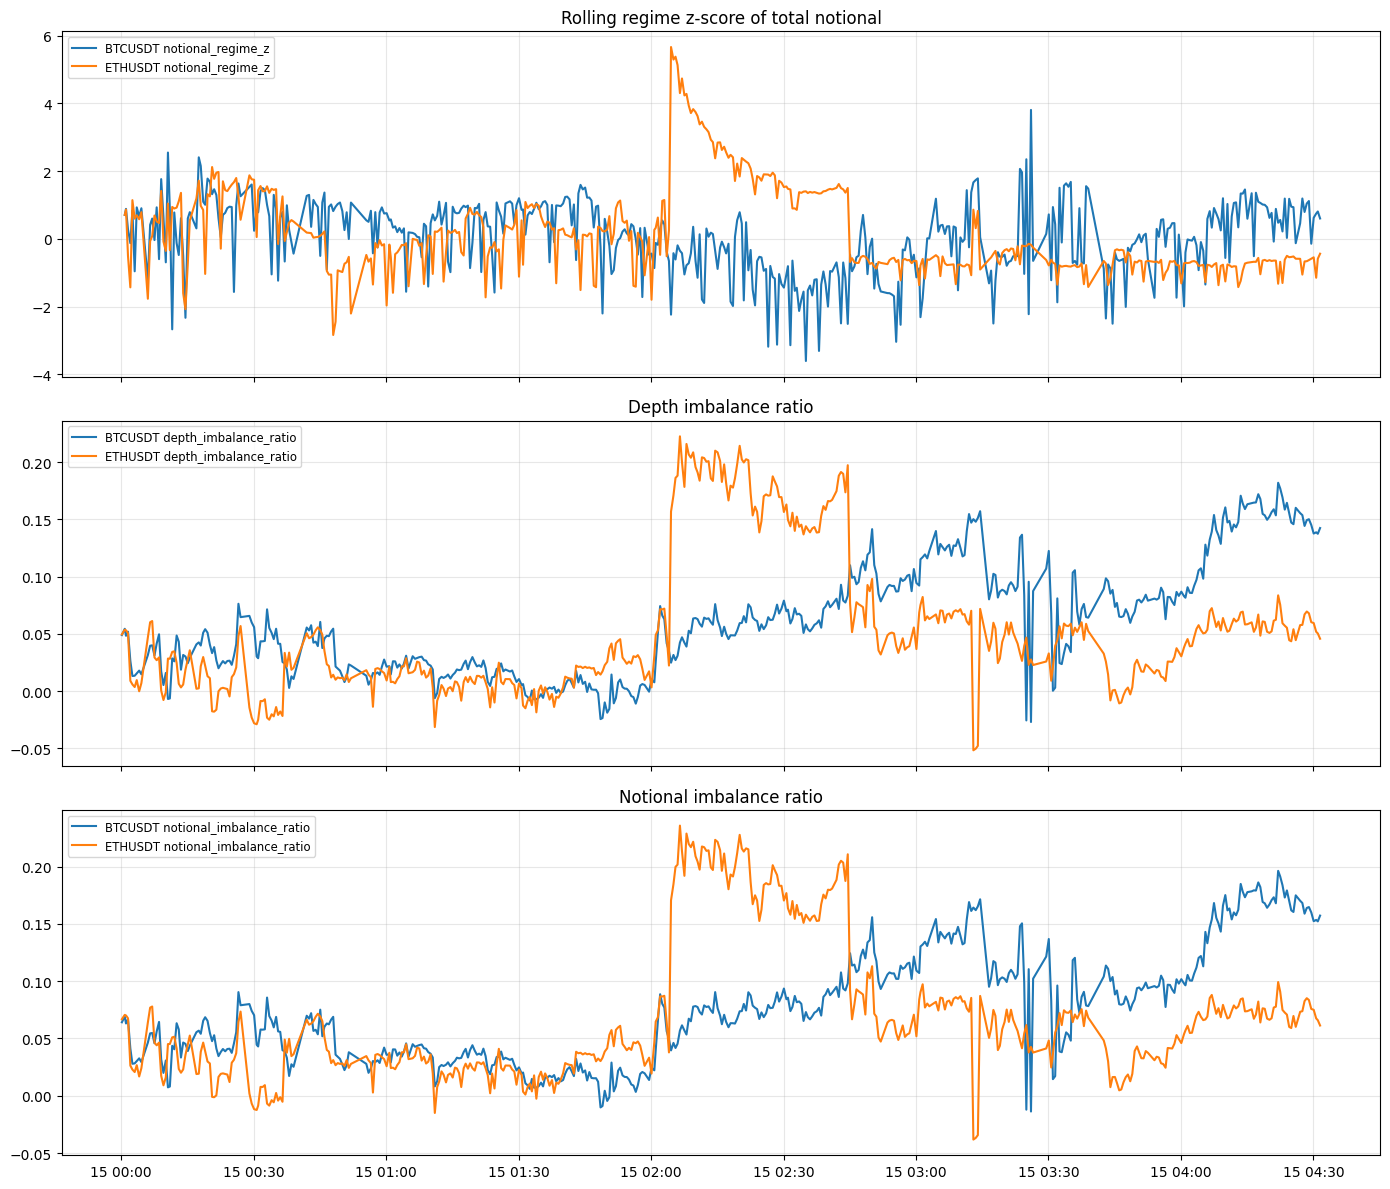

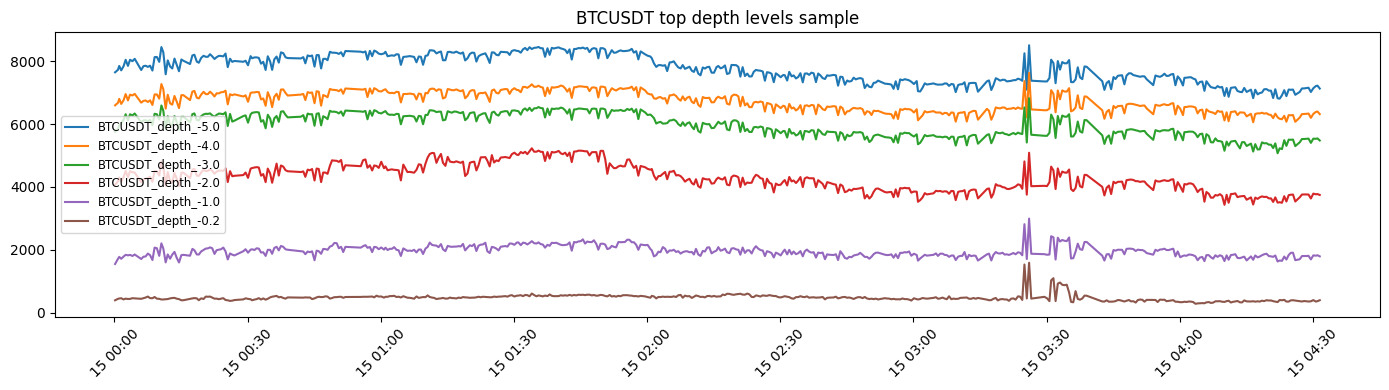

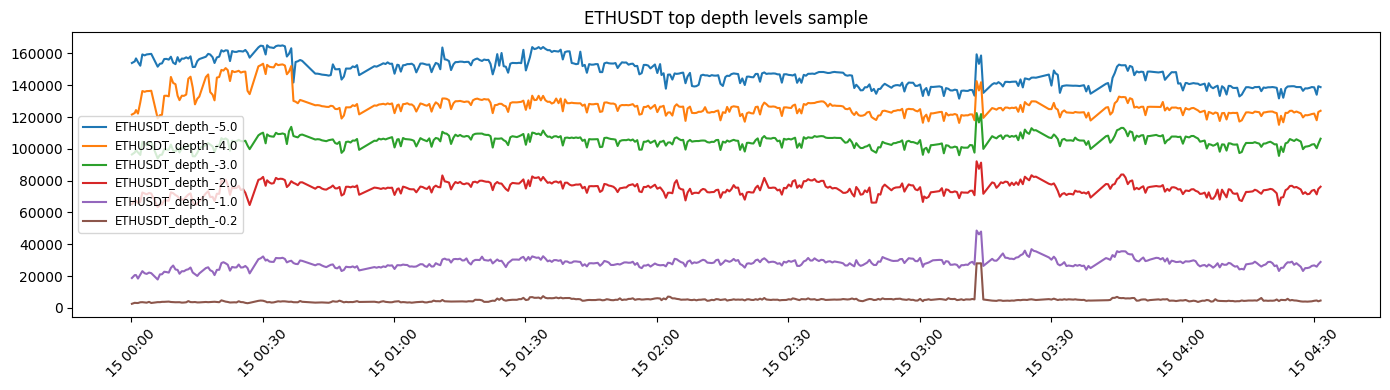

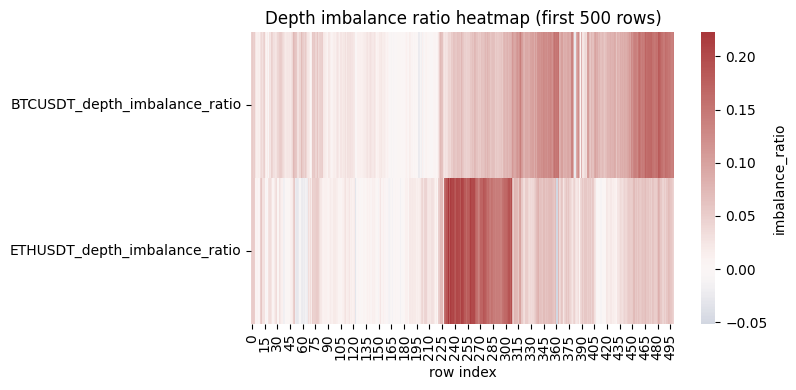

In [5]:
# Visualize some features to sanity check
import matplotlib.pyplot as plt
import seaborn as sns

# display only first 500 rows for checking
plot_df = df.copy().sort_values('timestamp').reset_index(drop=True).iloc[:500]

# 1) Plot normalized notional and imbalance ratios for each pair
fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
for pair in Trading_Pairs:
    if f"{pair}_notional_regime_z" in plot_df.columns:
        axs[0].plot(plot_df['timestamp'], plot_df[f"{pair}_notional_regime_z"], label=f"{pair} notional_regime_z")
    if f"{pair}_depth_imbalance_ratio" in plot_df.columns:
        axs[1].plot(plot_df['timestamp'], plot_df[f"{pair}_depth_imbalance_ratio"], label=f"{pair} depth_imbalance_ratio")
    if f"{pair}_notional_imbalance_ratio" in plot_df.columns:
        axs[2].plot(plot_df['timestamp'], plot_df[f"{pair}_notional_imbalance_ratio"], label=f"{pair} notional_imbalance_ratio")

axs[0].set_title('Rolling regime z-score of total notional')
axs[1].set_title('Depth imbalance ratio')
axs[2].set_title('Notional imbalance ratio')
for i in range(3):
    axs[i].legend(loc='upper left', fontsize='small')
    axs[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 2) compare top-of-book depth levels for BTCUSDT and ETHUSDT as stacked line chart
for pair in Trading_Pairs:
    depth_cols = [c for c in df.columns if c.startswith(pair + '_depth_') and c != f"{pair}_depth_imbalance"]
    if len(depth_cols) > 0:
        plt.figure(figsize=(14, 4))
        # pick a few levels to inspect
        for c in depth_cols[:6]:
            plt.plot(plot_df['timestamp'], plot_df[c].fillna(value='ffill'), label=c)
        plt.title(f'{pair} top depth levels sample')
        plt.legend(fontsize='small')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# 3) heatmap of imbalance ratio across pairs (if available)
if len(Trading_Pairs) > 0:
    heat_cols = [f"{pair}_depth_imbalance_ratio" for pair in Trading_Pairs if f"{pair}_depth_imbalance_ratio" in df.columns]
    if len(heat_cols) > 0:
        s = plot_df[heat_cols].copy()
        plt.figure(figsize=(8, 3 + 0.5 * len(heat_cols)))
        sns.heatmap(s.T, cmap='vlag', center=0, cbar_kws={'label': 'imbalance_ratio'})
        plt.title('Depth imbalance ratio heatmap (first 500 rows)')
        plt.xlabel('row index')
        plt.tight_layout()
        plt.show()


In [ ]:
# Bin trades into book depth snapshot intervals
# Each depth snapshot at T_i owns all trades in [T_i, T_{i+1})
from pathlib import Path
import pandas as pd
import numpy as np

# Sorted depth timestamps are our bin edges
depth_ts = df["timestamp"].sort_values().values

# Rolling z-score windows (in snapshot counts, ~30s each)
z_window_short = 120   # ~60 min
z_window_regime = 480  # ~240 min

trade_agg = {}  # pair -> aggregated df aligned to depth timestamps

for pair in Trading_Pairs:
    trade_path = Path("trades_data") / pair / f"{pair}_trades_merged.csv"
    if not trade_path.exists():
        print(f"No merged trade file for {pair} — skipping")
        continue

    raw = pd.read_csv(trade_path)
    raw["timestamp"] = pd.to_datetime(raw["time"], unit="ms", utc=True).dt.tz_localize(None)
    raw = raw.sort_values("timestamp").reset_index(drop=True)

    # Aggressor sides
    raw["buy_qty"]  = raw["qty"].where(~raw["is_buyer_maker"].astype(bool), 0.0)
    raw["sell_qty"] = raw["qty"].where( raw["is_buyer_maker"].astype(bool), 0.0)

    # Assign each trade to its depth snapshot: most recent depth_ts at or before trade time
    idx = np.searchsorted(depth_ts, raw["timestamp"].values, side="right") - 1
    idx = np.clip(idx, 0, len(depth_ts) - 1)
    raw["depth_timestamp"] = depth_ts[idx]

    # Aggregate per depth snapshot
    grouped = raw.groupby("depth_timestamp").agg(
        trade_count    = ("id",        "count"),
        trade_volume   = ("qty",       "sum"),
        trade_notional = ("quote_qty", "sum"),
        buy_volume     = ("buy_qty",   "sum"),
        sell_volume    = ("sell_qty",  "sum"),
    ).reset_index().rename(columns={"depth_timestamp": "timestamp"})

    # Compute VWAP internally, then replace with stationary derivatives
    # Raw VWAP is non-stationary (price level changes over time) bad for ML
    grouped["_vwap"] = grouped["trade_notional"] / grouped["trade_volume"].replace(0, np.nan)

    # vwap_return: tick-to-tick percentage change — captures price movement direction
    grouped["vwap_return"] = grouped["_vwap"].pct_change()
    # vwap_volatility: rolling std of returns — captures price instability
    grouped["vwap_volatility"] = grouped["vwap_return"].rolling(z_window_short, min_periods=1).std()
    grouped = grouped.drop(columns=["_vwap"])  # drop raw price — non-stationary

    # Buy/sell pressure
    grouped["buy_ratio"] = grouped["buy_volume"] / grouped["trade_volume"].replace(0, np.nan)
    grouped["trade_flow_imbalance"] = (
        (grouped["buy_volume"] - grouped["sell_volume"]) /
        grouped["trade_volume"].replace(0, np.nan)
    )

    # Rolling z-scores (at depth-snapshot resolution)
    log_count    = np.log1p(grouped["trade_count"])
    log_notional = np.log1p(grouped["trade_notional"])

    grouped["trade_intensity_z"] = (
        (log_count - log_count.rolling(z_window_short, min_periods=1).mean()) /
        log_count.rolling(z_window_short, min_periods=1).std().replace(0, np.nan)
    )
    grouped["trade_intensity_regime_z"] = (
        (log_count - log_count.rolling(z_window_regime, min_periods=1).mean()) /
        log_count.rolling(z_window_regime, min_periods=1).std().replace(0, np.nan)
    )
    grouped["trade_notional_z"] = (
        (log_notional - log_notional.rolling(z_window_short, min_periods=1).mean()) /
        log_notional.rolling(z_window_short, min_periods=1).std().replace(0, np.nan)
    )

    # Prefix columns with pair name
    grouped = grouped.rename(columns={
        col: f"{pair}_{col}" for col in grouped.columns if col != "timestamp"
    })

    trade_agg[pair] = grouped
    print(f"{pair}: {len(raw)} raw trades -> {len(grouped)} depth-aligned bins "
          f"(avg {len(raw)/max(len(grouped),1):.0f} trades/snapshot)")

BTCUSDT: 30609989 raw trades -> 15786 depth-aligned bins (avg 1939 trades/snapshot)
ETHUSDT: 50881839 raw trades -> 15786 depth-aligned bins (avg 3223 trades/snapshot)


In [ ]:
# trade bins are keyed on exact depth timestamps, so its a simple left join
df_with_trades = df.copy().sort_values("timestamp").reset_index(drop=True)

for pair, agg_df in trade_agg.items():
    df_with_trades = df_with_trades.merge(agg_df, on="timestamp", how="left")
    print(f"Merged {pair}: df now has {len(df_with_trades.columns)} columns")

trade_feature_cols = [c for c in df_with_trades.columns if any(
    tag in c for tag in ["trade_count", "trade_volume", "trade_notional", "buy_volume",
                         "sell_volume", "buy_ratio", "trade_flow_imbalance", "vwap_return",
                         "vwap_volatility", "trade_intensity_z", "trade_intensity_regime_z",
                         "trade_notional_z"]
)]
print(f"\nTrade feature columns ({len(trade_feature_cols)}):")
for c in trade_feature_cols:
    non_null = df_with_trades[c].notna().sum()
    print(f"  {c}: {non_null}/{len(df_with_trades)} non-null")

Merged BTCUSDT: df now has 93 columns
Merged ETHUSDT: df now has 105 columns

Trade feature columns (24):
  BTCUSDT_trade_count: 15786/15786 non-null
  BTCUSDT_trade_volume: 15786/15786 non-null
  BTCUSDT_trade_notional: 15786/15786 non-null
  BTCUSDT_buy_volume: 15786/15786 non-null
  BTCUSDT_sell_volume: 15786/15786 non-null
  BTCUSDT_vwap_return: 15785/15786 non-null
  BTCUSDT_vwap_volatility: 15784/15786 non-null
  BTCUSDT_buy_ratio: 15786/15786 non-null
  BTCUSDT_trade_flow_imbalance: 15786/15786 non-null
  BTCUSDT_trade_intensity_z: 15785/15786 non-null
  BTCUSDT_trade_intensity_regime_z: 15785/15786 non-null
  BTCUSDT_trade_notional_z: 15785/15786 non-null
  ETHUSDT_trade_count: 15786/15786 non-null
  ETHUSDT_trade_volume: 15786/15786 non-null
  ETHUSDT_trade_notional: 15786/15786 non-null
  ETHUSDT_buy_volume: 15786/15786 non-null
  ETHUSDT_sell_volume: 15786/15786 non-null
  ETHUSDT_vwap_return: 15785/15786 non-null
  ETHUSDT_vwap_volatility: 15784/15786 non-null
  ETHUSDT_buy

In [8]:
# Save combined dataset (book depth + trade features)
out_path = "bookDepth_data/all_pairs_with_trades.csv"
df_with_trades.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"  rows={len(df_with_trades)}, cols={len(df_with_trades.columns)}")
print(f"  Date range: {df_with_trades['timestamp'].min()} → {df_with_trades['timestamp'].max()}")
print(f"  Pairs: {Trading_Pairs}")


Saved: bookDepth_data/all_pairs_with_trades.csv
  rows=15786, cols=105
  Date range: 2026-03-15 00:00:08 → 2026-03-20 23:59:31
  Pairs: ['BTCUSDT', 'ETHUSDT']


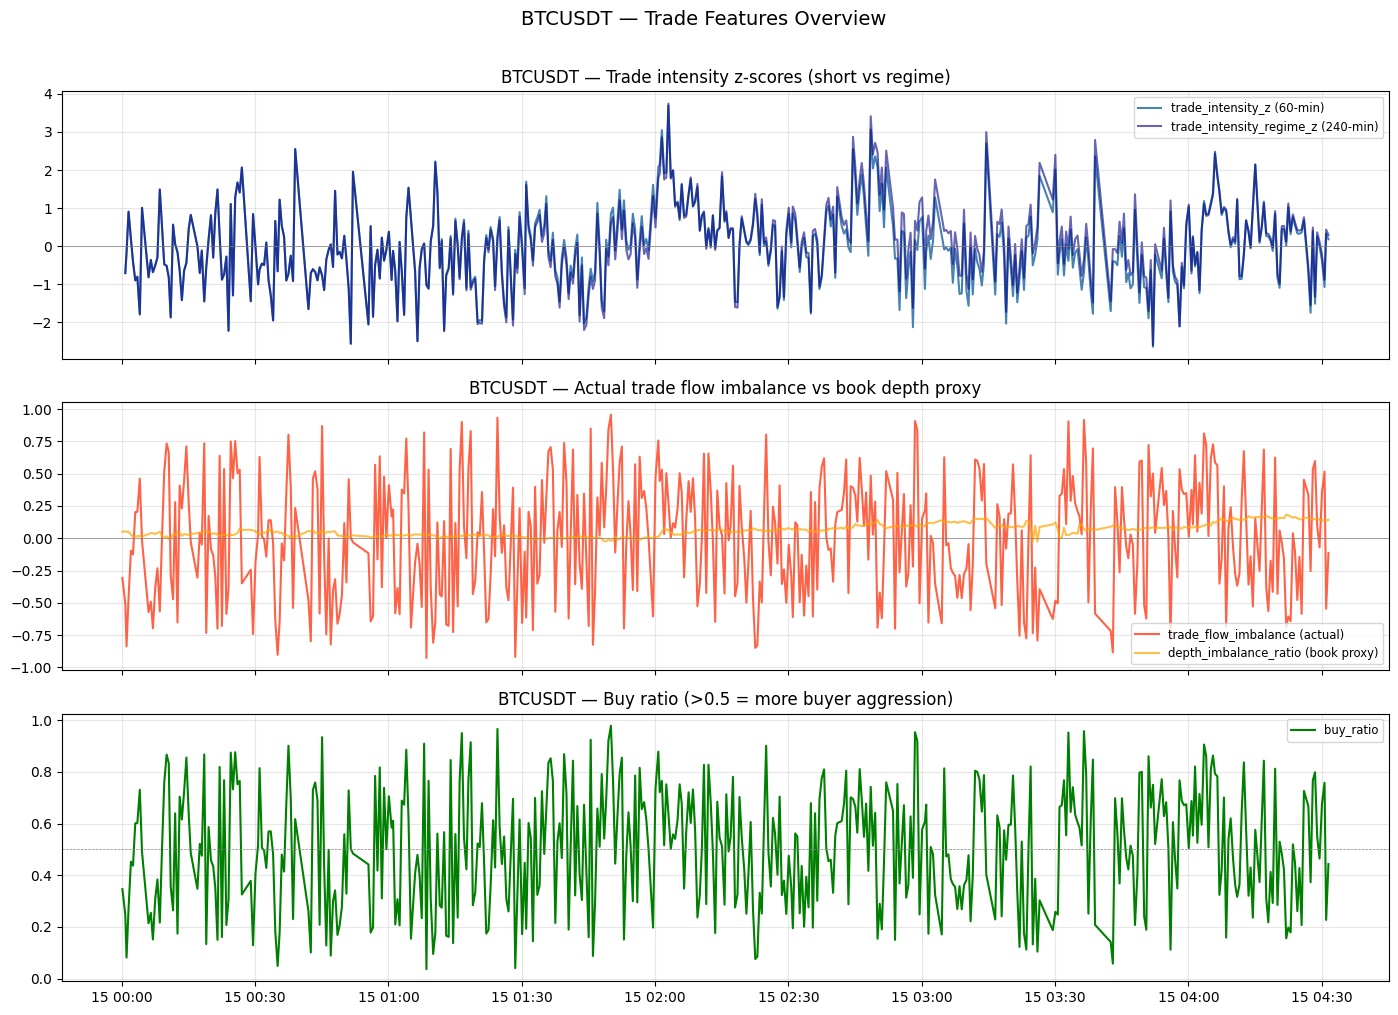

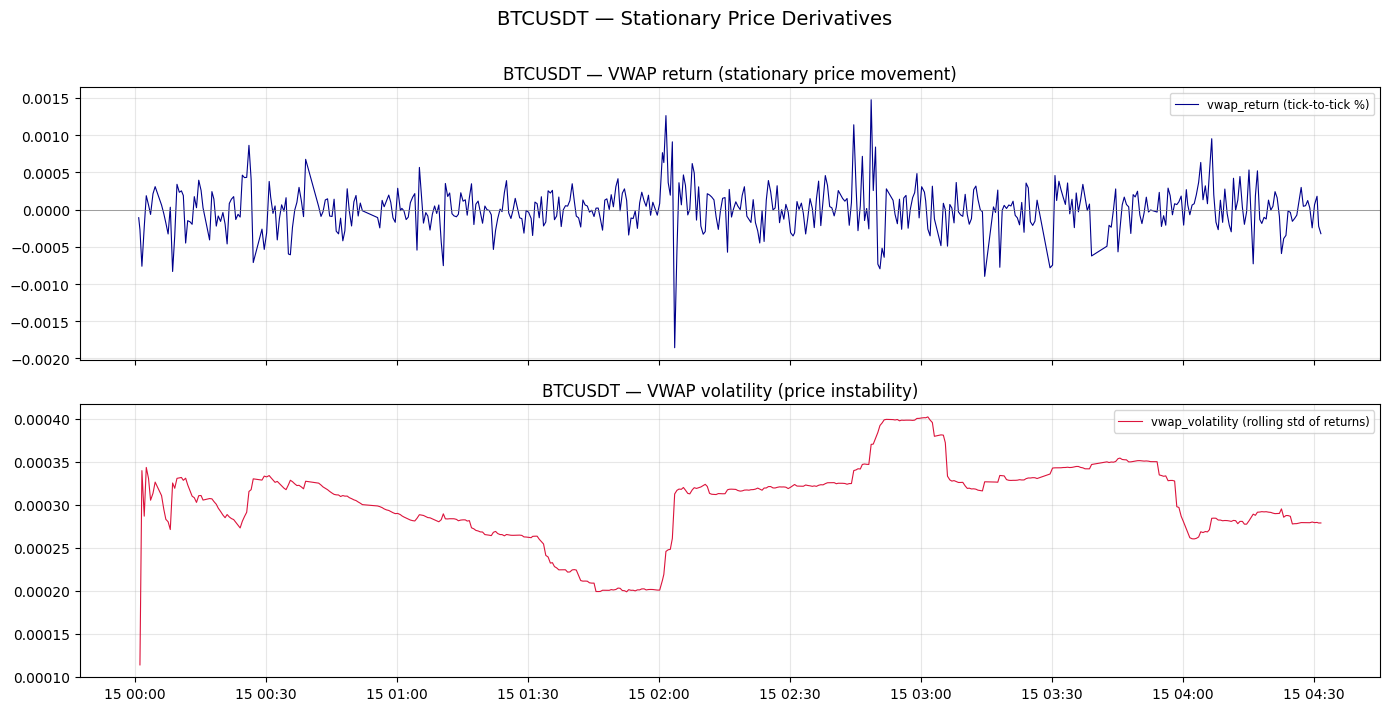

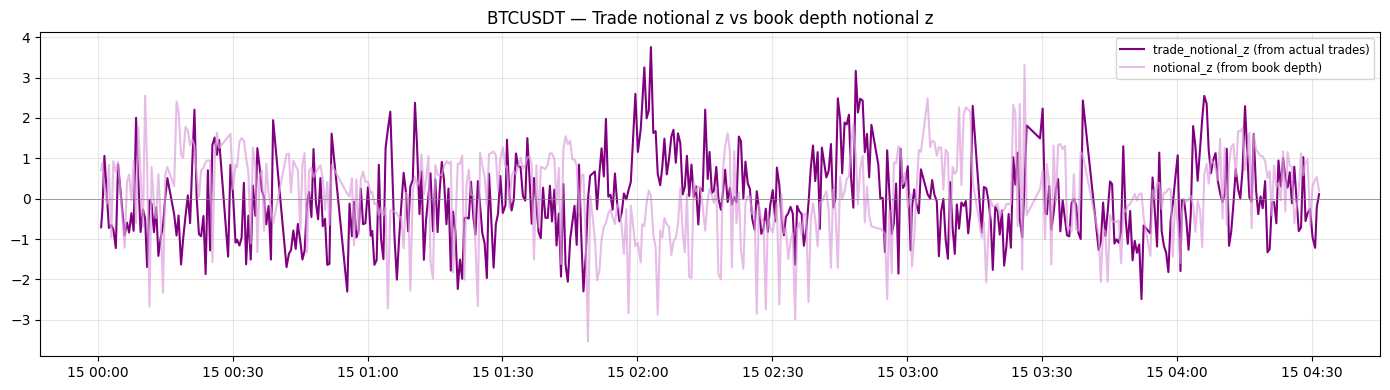

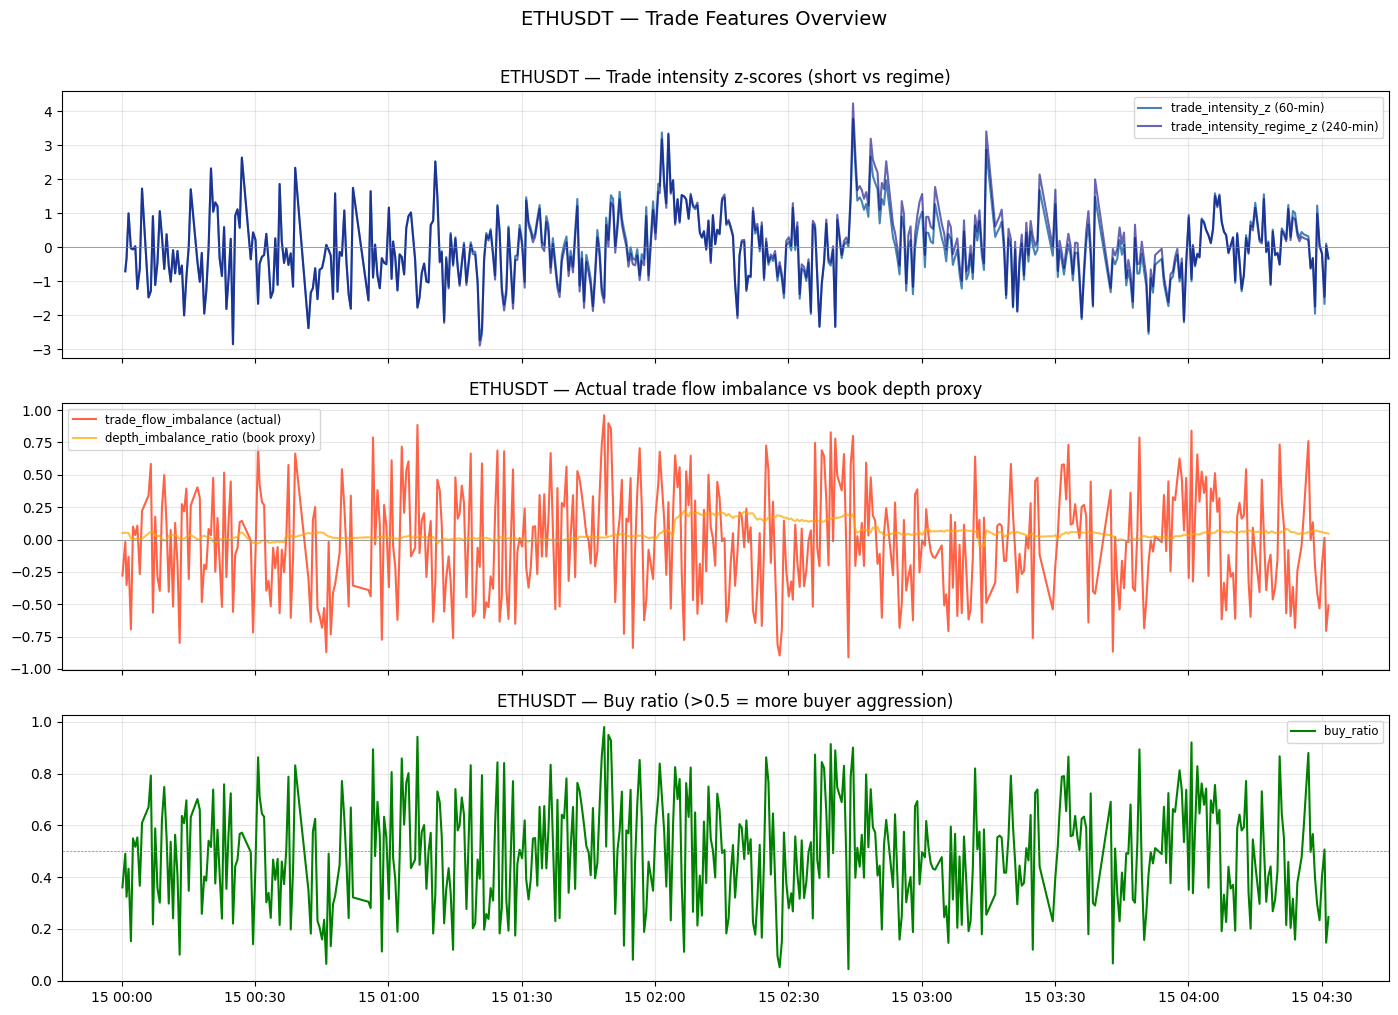

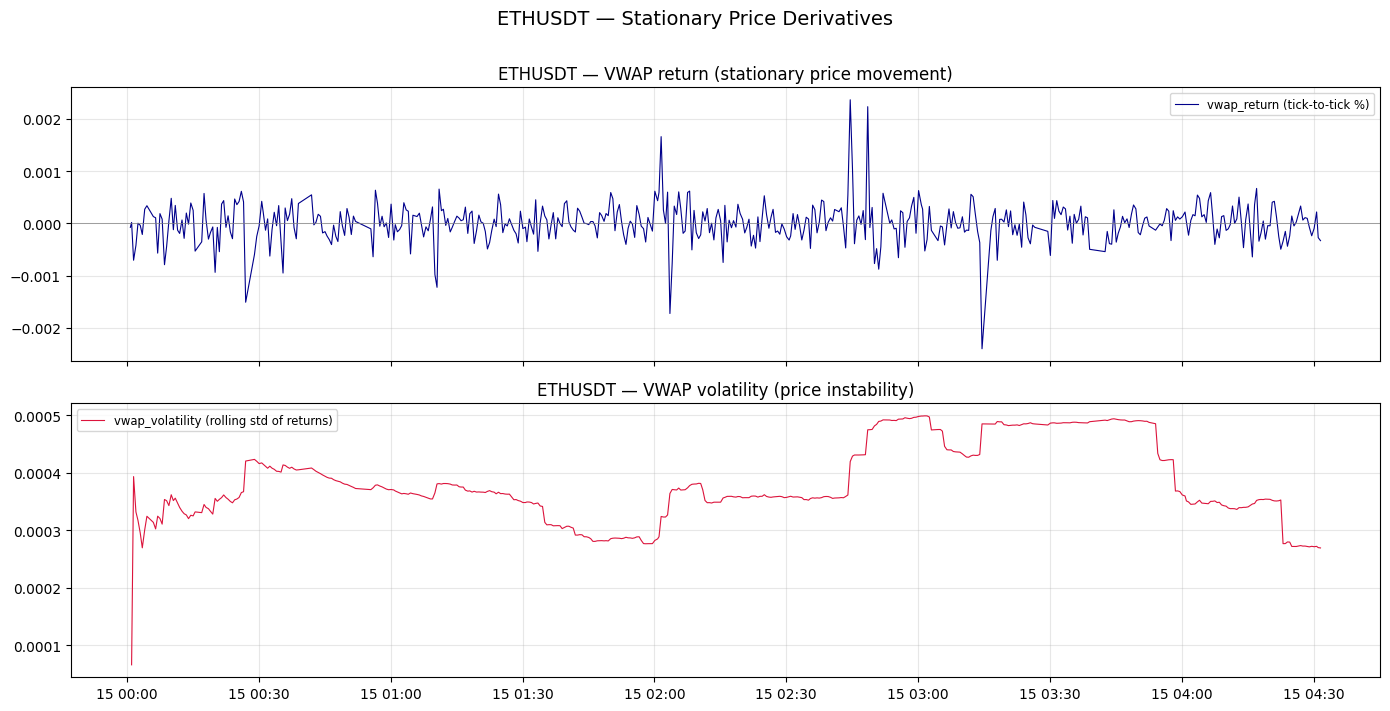

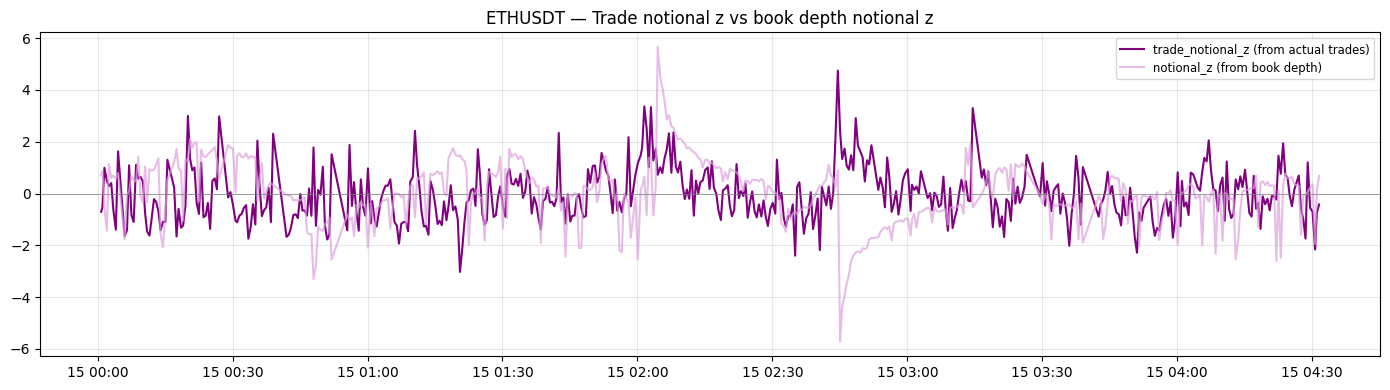

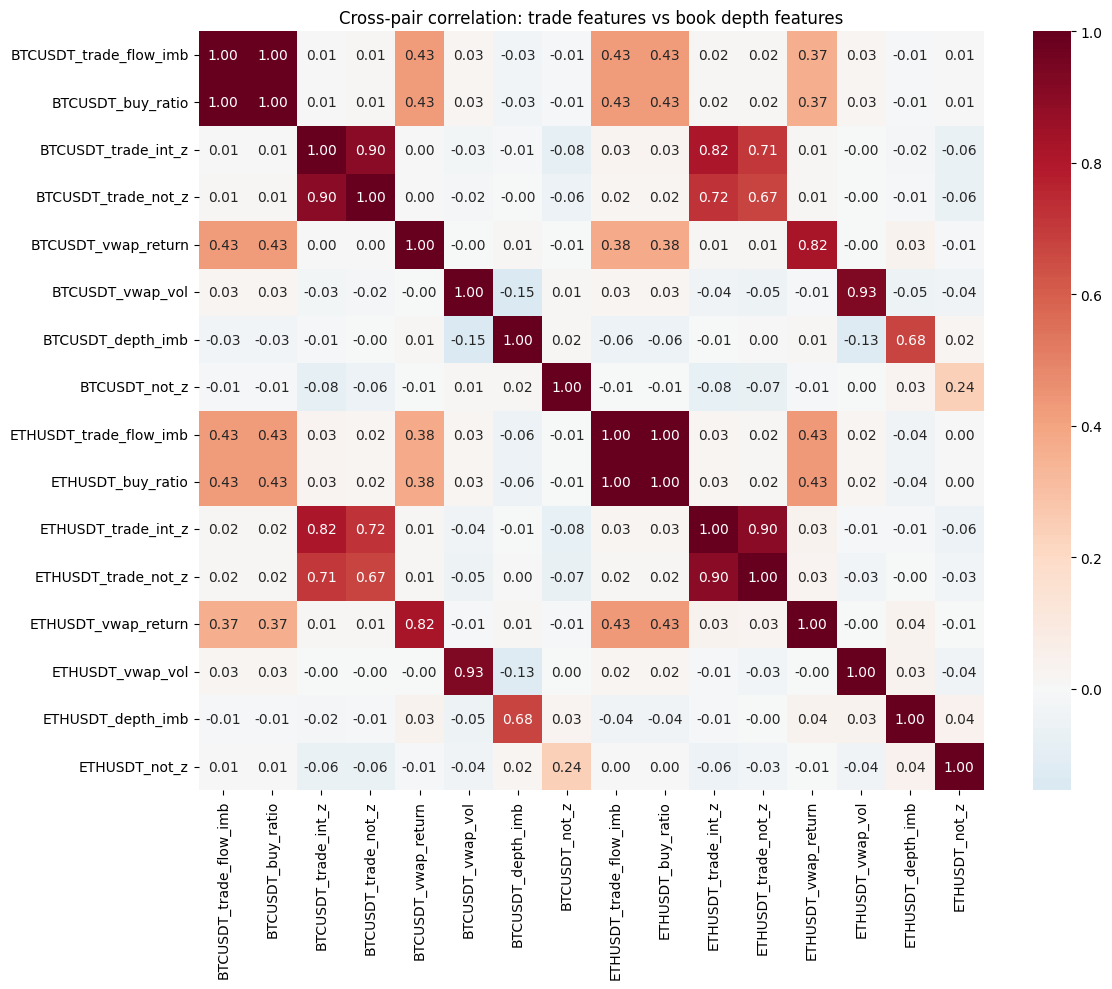

In [ ]:
# Visualization: trade features vs book depth features
import matplotlib.pyplot as plt
import seaborn as sns

plot_df_t = df_with_trades.sort_values("timestamp").reset_index(drop=True).iloc[:500]

for pair in Trading_Pairs:
    if f"{pair}_trade_flow_imbalance" not in plot_df_t.columns:
        continue

    # 1) Trade intensity: short z vs regime z
    fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    axs[0].plot(plot_df_t["timestamp"], plot_df_t[f"{pair}_trade_intensity_z"],
                label="trade_intensity_z (60-min)", color="steelblue")
    axs[0].plot(plot_df_t["timestamp"], plot_df_t[f"{pair}_trade_intensity_regime_z"],
                label="trade_intensity_regime_z (240-min)", color="navy", alpha=0.6)
    axs[0].axhline(0, color="gray", linewidth=0.5)
    axs[0].set_title(f"{pair} — Trade intensity z-scores (short vs regime)")
    axs[0].legend(fontsize="small"); axs[0].grid(alpha=0.3)

    # 2) Trade flow imbalance vs depth imbalance
    axs[1].plot(plot_df_t["timestamp"], plot_df_t[f"{pair}_trade_flow_imbalance"],
                label="trade_flow_imbalance (actual)", color="tomato")
    axs[1].plot(plot_df_t["timestamp"], plot_df_t[f"{pair}_depth_imbalance_ratio"],
                label="depth_imbalance_ratio (book proxy)", color="orange", alpha=0.7)
    axs[1].axhline(0, color="gray", linewidth=0.5)
    axs[1].set_title(f"{pair} — Actual trade flow imbalance vs book depth proxy")
    axs[1].legend(fontsize="small"); axs[1].grid(alpha=0.3)

    # 3) Buy ratio from trades
    axs[2].plot(plot_df_t["timestamp"], plot_df_t[f"{pair}_buy_ratio"],
                label="buy_ratio", color="green")
    axs[2].axhline(0.5, color="gray", linewidth=0.5, linestyle="--")
    axs[2].set_title(f"{pair} — Buy ratio (>0.5 = more buyer aggression)")
    axs[2].legend(fontsize="small"); axs[2].grid(alpha=0.3)

    plt.suptitle(f"{pair} — Trade Features Overview", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    # 4) VWAP return + volatility (stationary price derivatives) ---
    fig, axs = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    axs[0].plot(plot_df_t["timestamp"], plot_df_t[f"{pair}_vwap_return"],
                label="vwap_return (tick-to-tick %)", color="darkblue", linewidth=0.8)
    axs[0].axhline(0, color="gray", linewidth=0.5)
    axs[0].set_title(f"{pair} — VWAP return (stationary price movement)")
    axs[0].legend(fontsize="small"); axs[0].grid(alpha=0.3)

    axs[1].plot(plot_df_t["timestamp"], plot_df_t[f"{pair}_vwap_volatility"],
                label="vwap_volatility (rolling std of returns)", color="crimson", linewidth=0.8)
    axs[1].set_title(f"{pair} — VWAP volatility (price instability)")
    axs[1].legend(fontsize="small"); axs[1].grid(alpha=0.3)

    plt.suptitle(f"{pair} — Stationary Price Derivatives", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    # 5) Trade notional z vs book depth notional z
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(plot_df_t["timestamp"], plot_df_t[f"{pair}_trade_notional_z"],
            label="trade_notional_z (from actual trades)", color="purple")
    if f"{pair}_notional_z" in plot_df_t.columns:
        ax.plot(plot_df_t["timestamp"], plot_df_t[f"{pair}_notional_z"],
                label="notional_z (from book depth)", color="plum", alpha=0.7)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_title(f"{pair} — Trade notional z vs book depth notional z")
    ax.legend(fontsize="small"); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# 6) Cross-pair correlation heatmap
corr_cols = []
for pair in Trading_Pairs:
    corr_cols.extend([
        f"{pair}_trade_flow_imbalance",
        f"{pair}_buy_ratio",
        f"{pair}_trade_intensity_z",
        f"{pair}_trade_notional_z",
        f"{pair}_vwap_return",
        f"{pair}_vwap_volatility",
        f"{pair}_depth_imbalance_ratio",
        f"{pair}_notional_z",
    ])
corr_cols = [c for c in corr_cols if c in df_with_trades.columns]

if corr_cols:
    fig, ax = plt.subplots(figsize=(12, 10))
    corr = df_with_trades[corr_cols].corr()
    short_labels = [c.replace("_imbalance_ratio", "_imb").replace("_imbalance", "_imb")
                     .replace("_intensity", "_int").replace("_notional", "_not")
                     .replace("_volatility", "_vol")
                     for c in corr.columns]
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                xticklabels=short_labels, yticklabels=short_labels, ax=ax)
    ax.set_title("Cross-pair correlation: trade features vs book depth features")
    plt.tight_layout()
    plt.show()